### EX: Tracking the Gradient

In this exercise, we will train a Keras neural network to predict PGM impact coordinates and visualize the Gradient Descent process in action.

* **Generate Data:** Simulate wind speed, altitude, and release velocity to predict impact deviation.

* **Build Architecture:** Deploy a standard feedforward Keras model.

* **Train and Track:** We will train the model for 100 epochs and capture the `history` object, which records the Loss function's value at every step.

* **Visualize:** Plot the Loss Curve.

In [ ]:
#Only run this cell after selecting your kernel
!python.exe -m pip install --upgrade pip
!pip install numpy matplotlib scikit-learn pandas tensorflow

c:\Users\codeh\471Book\jnb_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Initiating Gradient Descent over 100 epochs...


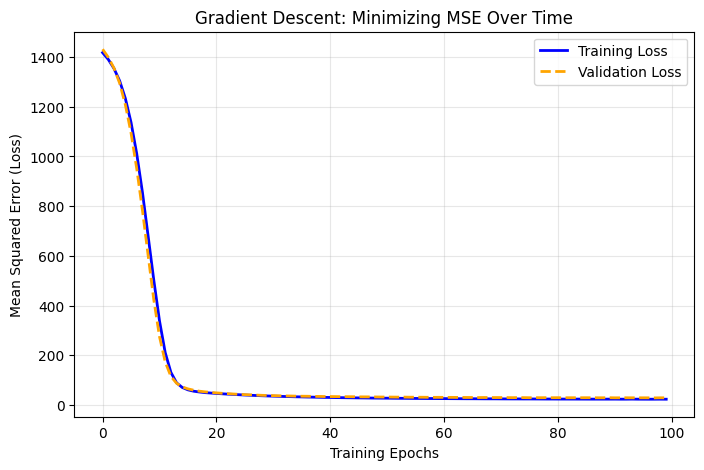

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Generate PGM Drop Data
np.random.seed(42)
n_drops = 1000
wind_speed = np.random.uniform(0, 50, n_drops)
altitude = np.random.uniform(10000, 30000, n_drops)
velocity = np.random.uniform(400, 600, n_drops)

X = np.column_stack((wind_speed, altitude, velocity))

# Target: Impact Deviation in meters
impact_deviation = (wind_speed * 1.5) + (altitude * 0.002) - (velocity * 0.1) + np.random.normal(0, 5, n_drops)

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, impact_deviation, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Build the Model
model = Sequential([
    Dense(32, activation='relu', input_shape=(3,)),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse')

# 3. Train the Model and Capture the History
print("Initiating Gradient Descent over 100 epochs...")
history = model.fit(X_train_scaled, y_train, epochs=100, validation_split=0.2, verbose=0)

# 4. Plot the Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='--')
plt.title('Gradient Descent: Minimizing MSE Over Time')
plt.xlabel('Training Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Interpreting the Results

The Loss Curve is the vital sign monitor of a neural network. Look at the steep drop in the first 20 epochs. This represents the network making massive weight updates, rapidly descending the gradient canyon. As the curve flattens out (epochs 40-100), the network is approaching the global minimum—the bottom of the canyon. The gradients are getting smaller, so the weight updates are getting smaller. The network is "dialing in" the final precision of the bomb fins.

Because both the Training Loss (blue) and Validation Loss (orange) decrease and remain tightly paired, we know the model is learning generalized rules successfully.
